In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import csv

# Case Study

## Sensitivity Comparison for Q1-Q4

In [2]:
plt.rcParams.update({'font.size': 20})

def read_sensitivity(filepath):
    with open(filepath, newline='') as f:
        reader = csv.reader(f)
        data = []
        for row in reader:
            if not row:
                continue
            data.append(int(row[1]))    
        return data

In [3]:
# Constants
policies = np.array([r'$\mathcal{P}^U$', r'$\mathcal{P}^B$', r'$\mathcal{P}^1$'])
queries = ['$Q1$', '$Q2$', '$Q3$', r'$Q4_{\text{SUM}}$', r'$Q4_{\text{CNT}}$']
colors = ['#9CCFC7', '#4FA3A5', '#E45756']
n_subgroups = 3
# cmap = plt.cm.Pastel2
# colors = cmap(range(n_subgroups))
bar_width = 0.2

# Data
data = []
data.append(read_sensitivity('university/q1_sensitivity.csv'))
data.append(read_sensitivity('university/q2_sensitivity.csv'))
data.append(read_sensitivity('university/q3_sensitivity.csv'))
data.append(read_sensitivity('university/q4_sensitivity.csv'))
data.append(read_sensitivity('university/q5_sensitivity.csv'))
data = np.array(data)

p1_data = data[:2, :]
p2_data = data[2:, :]

In [4]:
p1_data

array([[360, 792, 240],
       [360, 792,   0]])

In [5]:
p2_data

array([[24, 60, 60],
       [30, 60,  0],
       [ 6, 12,  0]])

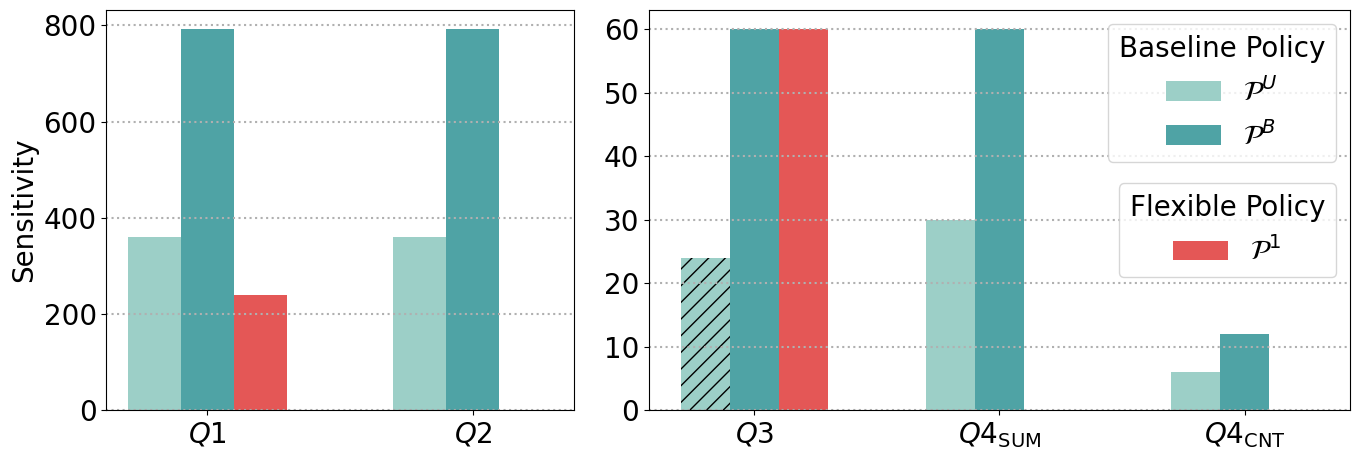

In [6]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
    gridspec_kw={'width_ratios': [2, 3]}
)
baseline_handles = []
flexible_handles = []

# Plot 1
x = np.arange(2)

for i in range(n_subgroups):
    bar = ax1.bar(x + i * bar_width, p1_data[:, i], width=bar_width, label=policies[i], color=colors[i])

ax1.set_ylabel('Sensitivity')
ax1.set_xticks(x + bar_width * (n_subgroups - 1) / 2)
ax1.set_xticklabels(queries[:2])
ax1.grid(axis='y', linestyle=':', linewidth=1.5)

x = np.arange(3)

for i in range(n_subgroups):
    bar = ax2.bar(x + i * bar_width, p2_data[:, i], width=bar_width, label=policies[i], color=colors[i])
    if i < 2:
        baseline_handles.append(Patch(facecolor=colors[i], label=policies[i]))
    else :
        flexible_handles.append(Patch(facecolor=colors[i], label=policies[i]))
    if i == 0:
        bar[0].set_hatch('//')

ax2.set_xticks(x + bar_width * (n_subgroups - 1) / 2)
ax2.set_xticklabels(queries[2:])
ax2.grid(axis='y', linestyle=':', linewidth=1.5)

baseline_legend = ax2.legend(ncol=1, handles=baseline_handles, title='Baseline Policy')
ax2.add_artist(baseline_legend)

ax2.legend(handles=flexible_handles, loc='center right', bbox_to_anchor=(1, 0.45), title='Flexible Policy')

plt.tight_layout()
plt.show()

# TPC-H Evaluation

## Sensitivity Comparison for Q1, Q4, Q13, and Q16

In [7]:
# Constants
customer_policies = np.array([r'$\mathcal{P}^U_{\bf{C}}$', r'$\mathcal{P}_{\bf{C}}$'])
supplier_policies = np.array([r'$\mathcal{P}^U_{\bf{S}}$', r'$\mathcal{P}_{\bf{S}}$'])
queries = [r'$\bf{Q1}$', r'$\bf{Q4}$', r'$\bf{Q13}$', r'$\bf{Q16}$']
colors = ['#9CCFC7', '#E45756']

# Data
data = []
data.append(read_sensitivity('tpch/q1_sensitivity.csv'))
data.append(read_sensitivity('tpch/q4_sensitivity.csv'))
data.append(read_sensitivity('tpch/q13_sensitivity.csv'))
data.append(read_sensitivity('tpch/q16_sensitivity.csv'))
data = np.array(data)

customer_data = data[:-1, :2]
supplier_data = np.delete(data[:, 2:], 2, axis=0)

num_groups = customer_data.shape[0]
num_bars = customer_data.shape[1]
bar_width = 0.25
x = np.arange(num_groups)

In [8]:
customer_data

array([[287, 287],
       [287, 287],
       [ 82, 164]])

In [9]:
supplier_data

array([[60080, 60080],
       [60080, 60080],
       [  160,     0]])

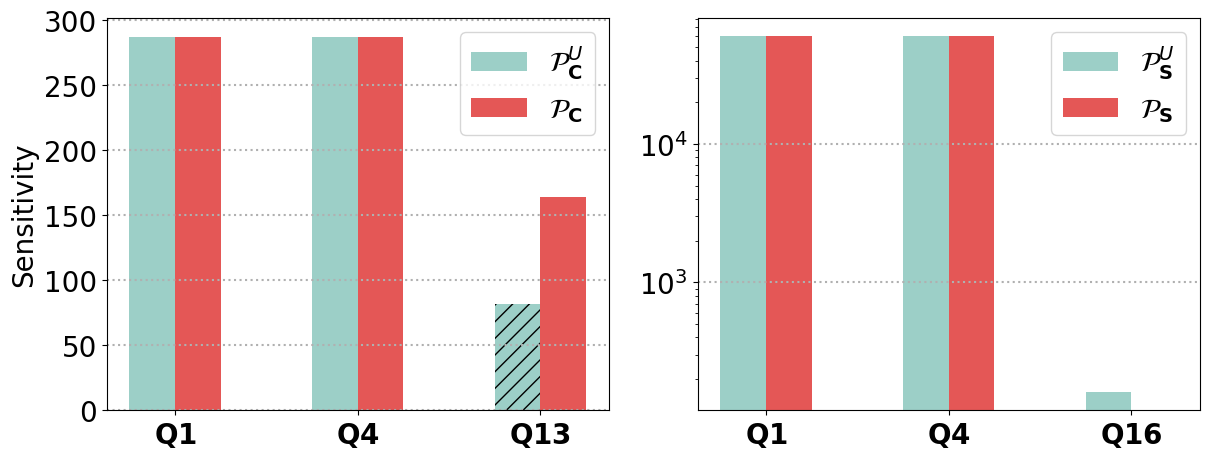

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
hatch = ''

# Customer
for i in range(num_bars):
    bar = ax1.bar(x + i * bar_width, customer_data[:, i], bar_width, label=customer_policies[i], color=colors[i], hatch=hatch)
    if i == 0:
        bar[2].set_hatch('//')

ax1.set_ylabel('Sensitivity')
ax1.set_xticks(x + bar_width / 2)
ax1.set_xticklabels(np.delete(queries, 3))
ax1.grid(axis='y', linestyle=':', linewidth=1.5)
ax1.legend(ncol=1)

# Supplier
for i in range(num_bars):
    ax2.bar(x + i * bar_width, supplier_data[:, i], bar_width, label=supplier_policies[i], color=colors[i])

ax2.set_xticks(x + bar_width / 2)
ax2.set_xticklabels(np.delete(queries, 2))
ax2.set_yscale('log')
ax2.grid(axis='y', linestyle=':', linewidth=1.5)
ax2.legend(ncol=1)

plt.tight_layout()
plt.show()

## Relative Error Comparison for Q1, Q4, Q13, and Q16

In [11]:
plt.rcParams.update({'font.size': 20})

def read_noise(filepath):
    with open(filepath, newline='') as f:
        reader = csv.reader(f)
        data = []
        for row in reader:
            if not row:
                continue
            data.append(row[1:])    
        return data

In [12]:
customer_policies = np.array([r'$\text{Tumult}_{\bf{C}}$', r'$\mathcal{P}^U_{\bf{C}}$', r'$\mathcal{P}_{\bf{C}}$'])
supplier_policies = np.array([r'$\text{Tumult}_{\bf{S}}$', r'$\mathcal{P}^U_{\bf{S}}$', r'$\mathcal{P}_{\bf{S}}$'])

# DP4SQL
data = []
data.append(read_noise('tpch/q1_noise.csv'))
data.append(read_noise('tpch/q4_noise.csv'))
data.append(read_noise('tpch/q13_noise.csv'))
data.append(read_noise('tpch/q16_noise.csv'))
data = np.array(data).astype(float)

# Tumult Analytics
customer = np.array(read_noise('tpch-opendp_tmlt/tumult_customer_error.csv')).astype(float)
supplier = np.array(read_noise('tpch-opendp_tmlt/tumult_supplier_error.csv')).astype(float)
customer = np.append(customer, np.zeros((1, 50)), axis=0)
supplier = np.insert(supplier, 2, np.zeros((1, 50)), axis=0)

data = np.insert(data, 0, customer, axis=1)
data = np.insert(data, 3, supplier, axis=1)

# Scaling for relative error
data[0, :, :] /= 1478493
data[1, :, :] /= 10594
data[2, :, :] /= 6641
data[3, :, :] /= 28

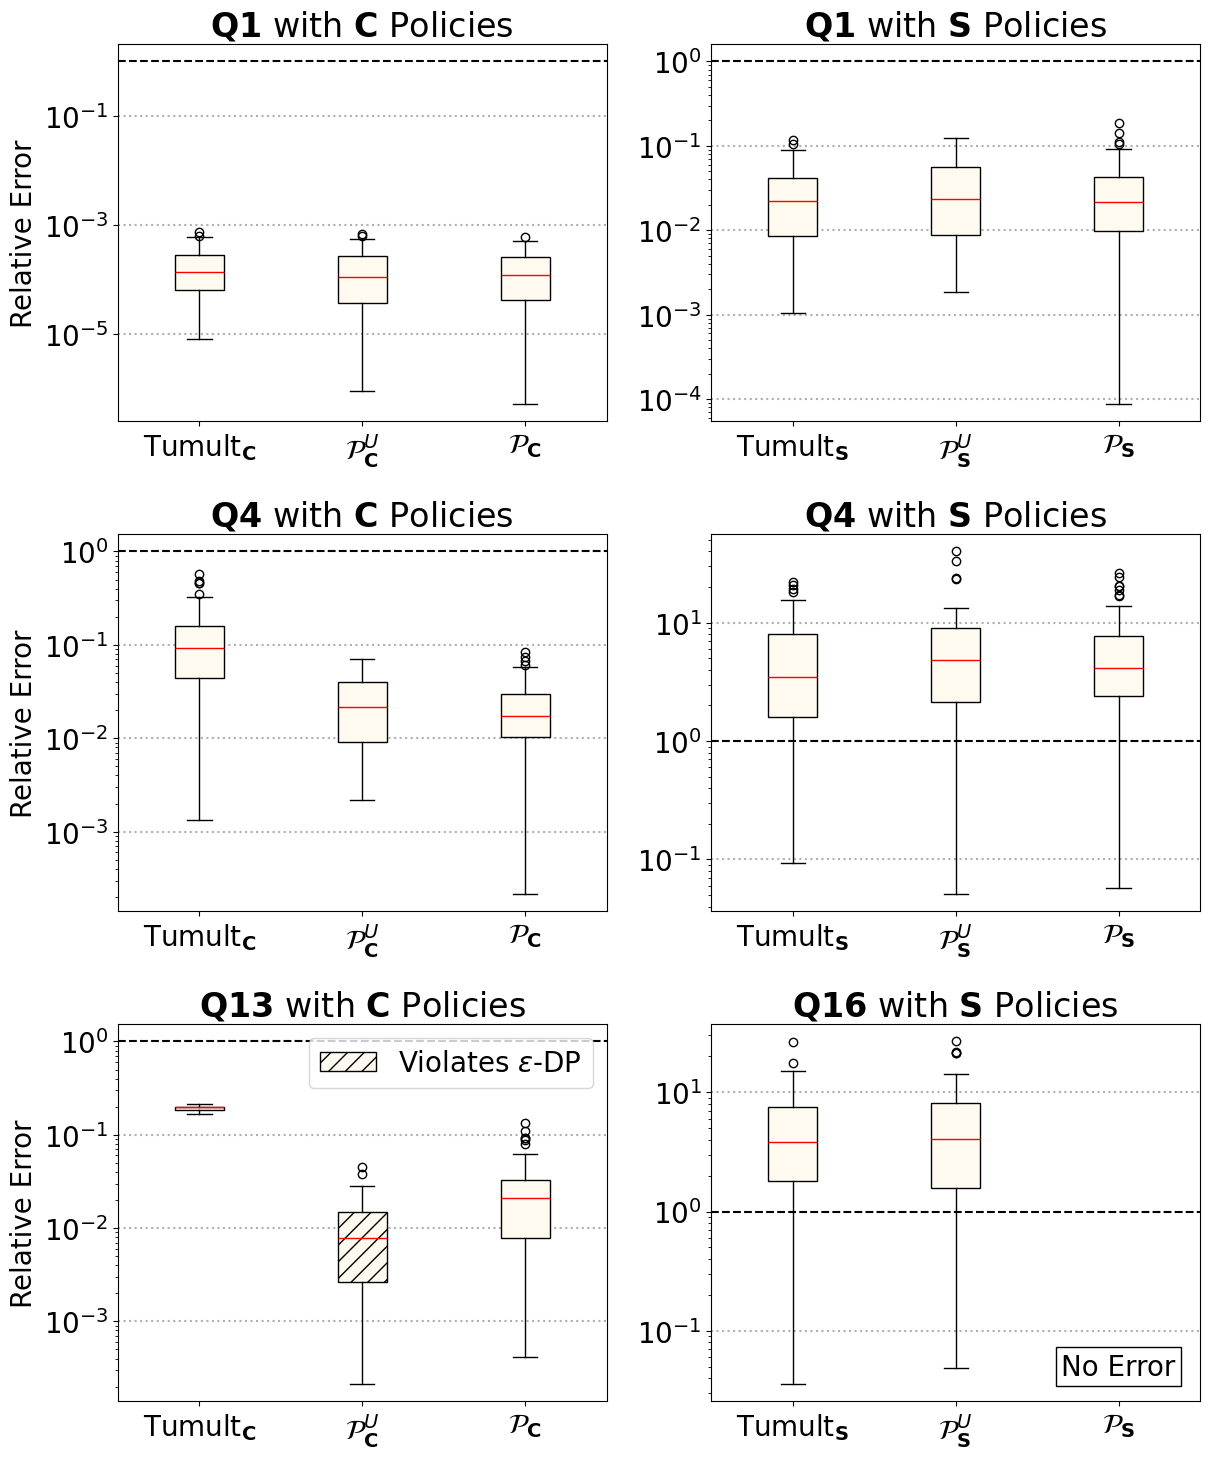

In [13]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(12.5, 15))

# Q1
bp1 = ax1.boxplot(
    data[0, 0:3, :].T,
    tick_labels=customer_policies,
    patch_artist=True,
    boxprops=dict(facecolor="floralwhite", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax1.set_title(r'$\bf{Q1}$ with $\bf{C}$ Policies')
ax1.set_ylabel("Relative Error")
ax1.set_yscale('log')
ax1.grid(axis='y', linestyle=':', linewidth=1.5)
ax1.axhline(1, color='black', linewidth=1.5, ls='--')

bp2 = ax2.boxplot(
    data[0, 3:, :].T,
    tick_labels=supplier_policies,
    patch_artist=True,
    boxprops=dict(facecolor="floralwhite", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax2.set_title(r'$\bf{Q1}$ with $\bf{S}$ Policies')
ax2.set_yscale('log')
ax2.grid(axis='y', linestyle=':', linewidth=1.5)
ax2.axhline(1, color='black', linewidth=1.5, ls='--')

# Q4
bp3 = ax3.boxplot(
    data[1, 0:3, :].T,
    tick_labels=customer_policies,
    patch_artist=True,
    boxprops=dict(facecolor="floralwhite", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax3.set_title(r'$\bf{Q4}$ with $\bf{C}$ Policies')
ax3.set_ylabel("Relative Error")
ax3.set_yscale('log')
ax3.grid(axis='y', linestyle=':', linewidth=1.5)
ax3.axhline(1, color='black', linewidth=1.5, ls='--')

bp4 = ax4.boxplot(
    data[1, 3:, :].T,
    tick_labels=supplier_policies,
    patch_artist=True,
    boxprops=dict(facecolor="floralwhite", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax4.set_title(r'$\bf{Q4}$ with $\bf{S}$ Policies')
ax4.set_yscale('log')
ax4.grid(axis='y', linestyle=':', linewidth=1.5)
ax4.axhline(1, color='black', linewidth=1.5, ls='--')

# Q13
bp5 = ax5.boxplot(
    data[2, 0:3, :].T,
    tick_labels=customer_policies,
    patch_artist=True,
    boxprops=dict(facecolor="floralwhite", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
bp5["boxes"][1].set_hatch("//")
bp5["boxes"][1].set_label(r"Violates $\epsilon$-DP")
ax5.set_title(r'$\bf{Q13}$ with $\bf{C}$ Policies')
ax5.set_ylabel("Relative Error")
ax5.set_yscale('log')
ax5.grid(axis='y', linestyle=':', linewidth=1.5)
ax5.axhline(1, color='black', linewidth=1.5, ls='--')
ax5.legend()

# Q16
bp6 = ax6.boxplot(
    data[3, 3:, :].T,
    tick_labels=supplier_policies,
    patch_artist=True,
    boxprops=dict(facecolor="floralwhite", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)
ax6.text(3, 0.05, 'No Error', ha="center", va="center", 
    bbox=dict(
        facecolor="white",
        edgecolor="black"
))
ax6.set_title(r'$\bf{Q16}$ with $\bf{S}$ Policies')
ax6.set_yscale('log')
ax6.grid(axis='y', linestyle=':', linewidth=1.5)
ax6.axhline(1, color='black', linewidth=1.5, ls='--')

plt.tight_layout()
plt.show()

In [14]:
boxplots = [bp1, bp2, bp3, bp4, bp5, bp6]

for i, bp in enumerate(boxplots):
    medians = [item.get_ydata()[0] for item in bp['medians']]
    print(f'Plot {i} Median Values: {medians}')

Plot 0 Median Values: [0.0001413601552391523, 0.00011461516758291246, 0.0001244390468615973]
Plot 1 Median Values: [0.02241708279985093, 0.023589528163440333, 0.021594801239016942]
Plot 2 Median Values: [0.09335472909193883, 0.021663628289455297, 0.01754279648116769]
Plot 3 Median Values: [3.4965074570511607, 4.806691260817562, 4.182760877437426]
Plot 4 Median Values: [0.1962806806203885, 0.0078824792375188, 0.020794800692803293]
Plot 5 Median Values: [3.8392857142857144, 4.065162170110623, 0.0]
